In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
coins = cv2.imread(r"images\SPOILER_coins_image.jpg")
dogs = cv2.imread(r"images\SPOILER_dog.jpg")
shapes = cv2.imread(r"images\SPOILER_shapes.jpg")

In [3]:
def generate_new_images(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    imgs = {}


    # generate flipped images
    imgs["horizontal_flip"] = cv2.flip(img, 1)
    imgs["vertical_flip"] = cv2.flip(img, 0)
    imgs["both_flip"] = cv2.flip(img, -1)


    #Lighting Variations
    alpha_values = [0.7, 0.9, 1.3]   # contrast
    beta_values = [-30, 15, 30]       # brightness

    for i, (a, b) in enumerate(zip(alpha_values, beta_values)):
        adjusted = img.astype(np.float32) * a + b
        adjusted = np.clip(adjusted, 0, 255).astype(np.uint8)
        imgs[f"Lighting_Variations_{i+1}"] = adjusted


    #rotation
    center = (img.shape[1] // 2, img.shape[0] // 2)
    angle = 30
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1)
    rotated_image = cv2.warpAffine(img, rotation_matrix, (img.shape[1], img.shape[0]))
    imgs["rotated"] = rotated_image


    # Gaussian Noise
    mean = 0
    std = 25
    noise = np.random.normal(mean, std, img.shape).astype(np.uint8)
    noisy = img.astype(np.float32) + noise
    imgs["Gaussian_Noise"] = np.clip(noisy, 0, 255).astype(np.uint8)


    # salt and pepper noise
    sp_noise_img = img.copy()
    h, w = img.shape[0], img.shape[1]
    noise_num = int(h * w * 0.03) # 0.03 is noise ratio

    for _ in range(noise_num):
        sp = np.random.randint(0, 2) * 255 # select salt or pepper randomly (0 or 255)
        r,c = np.random.randint(0, h) , np.random.randint(0, w) # select random pixel
        sp_noise_img[r,c] = sp
    imgs["salt_and_pepper_noise"] = sp_noise_img

    return imgs

In [4]:
# images = generate_new_images(dogs)
# for key in images:
#     cv2.imshow(key, images[key])
# cv2.waitKey(0)
# cv2.destroyAllWindows()


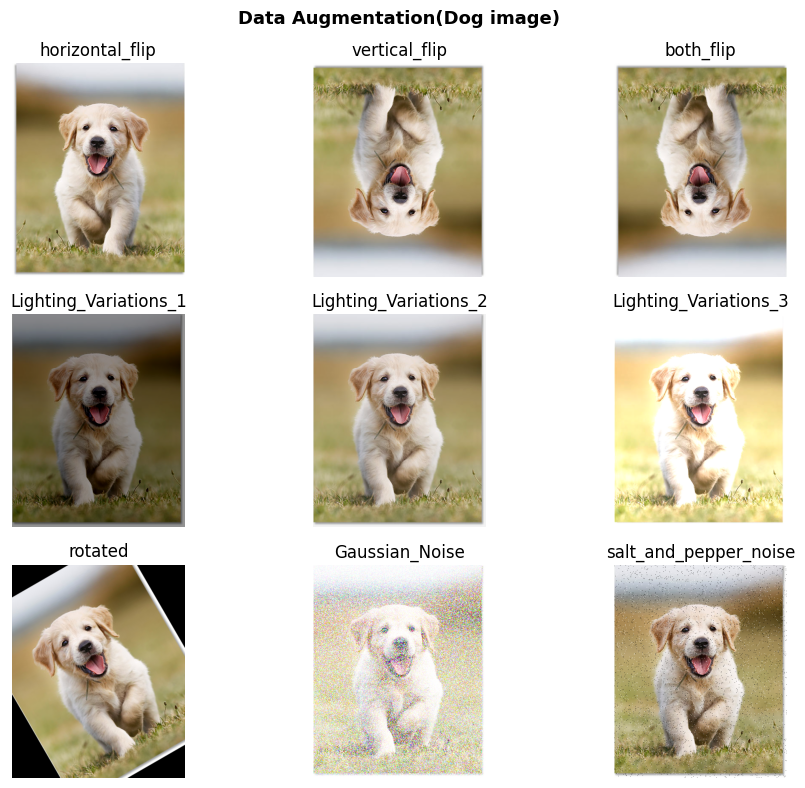

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(10, 8))

images = generate_new_images(dogs)

for ax, key in zip(axes.flat, images):
    ax.imshow(images[key])
    ax.set_title(key, fontsize=12)
    ax.axis('off')


plt.suptitle("Data Augmentation(Dog image)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()